# 1- Importing Libraries and Data.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
df = pd.read_csv("turnover.csv")

# 2- Exploring the Data.

In [ ]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [ ]:
df.groupby("left")[["satisfaction_level",	"last_evaluation", "number_project", "average_montly_hours", "time_spend_company"]].mean()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company
left,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032
1,0.440098,0.718113,3.855503,207.419210,3.876505


In [ ]:
df["left"].value_counts(normalize=True)

,proportion
left,
0,0.761917
1,0.238083


In [ ]:
df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
sales,0
salary,0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 3008


In [ ]:
df["sales"].unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

In [ ]:
df["salary"].unique()

array(['low', 'medium', 'high'], dtype=object)

# 3-  Cleaning the Data.

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_montly_hours   11991 non-null  int64  
 4   time_spend_company     11991 non-null  int64  
 5   Work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   sales                  11991 non-null  object 
 9   salary                 11991 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.0+ MB


# 4- Visualizing the Data.

# 5- Preprocessing the Data.

In [ ]:
df_encoded = pd.get_dummies(df, columns=["sales"], drop_first=True, dtype=int)

salary_map = {"low": 0, "medium": 1, "high": 2}
df_encoded["salary"] = df_encoded["salary"].map(salary_map)

In [ ]:
df_encoded.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,1,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,1,0,0


In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_montly_hours   11991 non-null  int64  
 4   time_spend_company     11991 non-null  int64  
 5   Work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   salary                 11991 non-null  int64  
 9   sales_RandD            11991 non-null  int64  
 10  sales_accounting       11991 non-null  int64  
 11  sales_hr               11991 non-null  int64  
 12  sales_management       11991 non-null  int64  
 13  sales_marketing        11991 non-null  int64  
 14  sales_product_mng      11991 non-null  int64  
 15  sales_s

In [ ]:
X = df_encoded.drop("left", axis=1)
y = df_encoded["left"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9592, 17), (2399, 17), (9592,), (2399,))

# 6- Implementing Decision Tree (DT) Model.

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [2, 5, 10, 20]
}

grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search_dt.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [2, 5, 10, 20],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='f1')

In [ ]:
best_dt = grid_search_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test)

In [ ]:
print(f"Best Parameters for Decision Tree:\n{grid_search_dt.best_params_}")

Best Parameters for Decision Tree:
{'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 20}


In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2001
           1       0.99      0.92      0.96       398

    accuracy                           0.99      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.99      0.99      0.99      2399



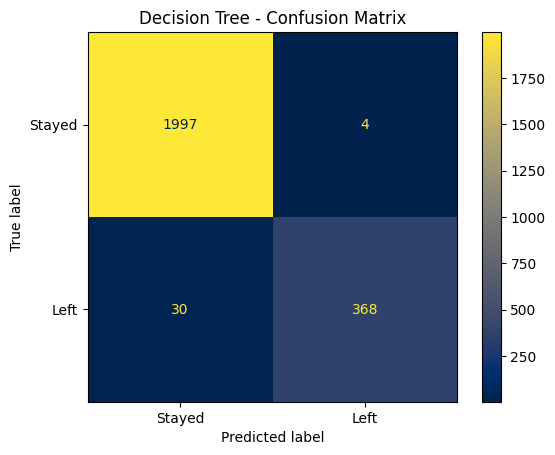

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp_dt = ConfusionMatrixDisplay(cm_dt, display_labels=["Stayed", "Left"])
disp_dt.plot(cmap="cividis")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

# 7- Implementing Random Forest (RF) Model.

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

param_grid_rf = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [2, 5, 10, 20]
}

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [2, 5, 10, 20],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='f1')

In [ ]:
best_rf = grid_search_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

In [ ]:
print(f"Best Parameters for Random Forest:\n{grid_search_rf.best_params_}")

Best Parameters for Random Forest:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2001
           1       0.98      0.92      0.95       398

    accuracy                           0.98      2399
   macro avg       0.98      0.96      0.97      2399
weighted avg       0.98      0.98      0.98      2399



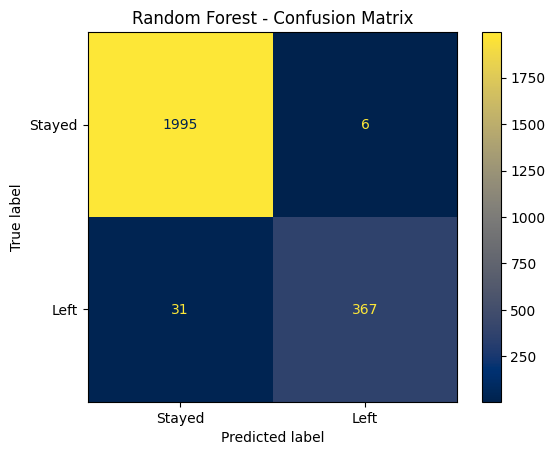

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=["Stayed", "Left"])
disp_rf.plot(cmap="cividis")
plt.title("Random Forest - Confusion Matrix")
plt.show()

# 9- Evaluating the Difference Between DT and RF Models.

In [ ]:
# 9- Evaluating the Difference Between DT and RF Models

accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_dt = precision_score(y_test, y_pred_dt)
precision_rf = precision_score(y_test, y_pred_rf)

recall_dt = recall_score(y_test, y_pred_dt)
recall_rf = recall_score(y_test, y_pred_rf)

f1_dt = f1_score(y_test, y_pred_dt)
f1_rf = f1_score(y_test, y_pred_rf)

print("Decision Tree:")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

print("\nRandom Forest:")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Decision Tree:
Accuracy : 0.9858274280950396
Precision: 0.989247311827957
Recall   : 0.9246231155778895
F1 Score : 0.9558441558441558

Random Forest:
Accuracy : 0.9845769070446019
Precision: 0.9839142091152815
Recall   : 0.9221105527638191
F1 Score : 0.9520103761348897


In [ ]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Decision Tree": [
        accuracy_dt,
        precision_dt,
        recall_dt,
        f1_dt
    ],
    "Random Forest": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf
    ]
})

print(comparison)

      Metric  Decision Tree  Random Forest
0   Accuracy       0.985827       0.984577
1  Precision       0.989247       0.983914
2     Recall       0.924623       0.922111
3   F1 Score       0.955844       0.952010


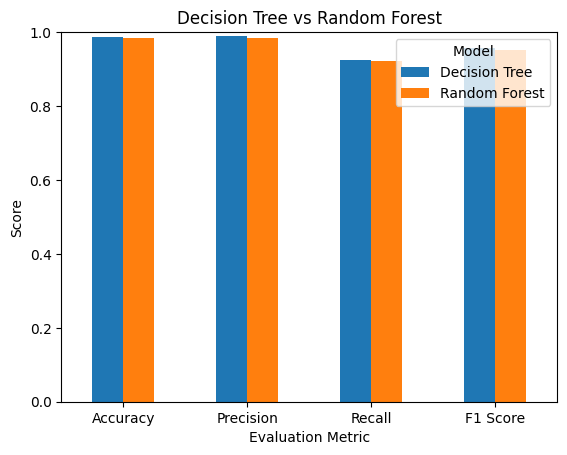

In [ ]:
comparison.set_index("Metric").plot(kind="bar")

plt.title("Decision Tree vs Random Forest")
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Model")
plt.show()